PREY & PREDITOR MODEL

In [169]:
import matplotlib.pyplot as plt
import numpy as np

About the steady states, there is a trivial steady state thhat is when both prey and preditor are equal to zero. and another one is when x = gamma/delta and y = aplha/delta


In [170]:
def r_dot(r, f, c_arr):
    return (c_arr[0] * r) - (c_arr[1] * r * f)

def f_dot(r, f, c_arr):  
    return -(c_arr[2] * f) + (c_arr[3] * r * f)

In [171]:
def rk4_step(r, f, h, c_arr, r_dot_func, f_dot_func):

    k1_r = r_dot_func(r, f, c_arr)
    k1_f = f_dot_func(r, f, c_arr)
    
    k2_r = r_dot_func(r + 0.5*h*k1_r, f + 0.5*h*k1_f, c_arr)
    k2_f = f_dot_func(r + 0.5*h*k1_r, f + 0.5*h*k1_f, c_arr)
    
    k3_r = r_dot_func(r + 0.5*h*k2_r, f + 0.5*h*k2_f, c_arr)
    k3_f = f_dot_func(r + 0.5*h*k2_r, f + 0.5*h*k2_f, c_arr)
    
    k4_r = r_dot_func(r + h*k3_r, f + h*k3_f, c_arr)
    k4_f = f_dot_func(r + h*k3_r, f + h*k3_f, c_arr)

    r_next = r + (h/6)*(k1_r + 2*k2_r + 2*k3_r + k4_r)
    f_next = f + (h/6)*(k1_f + 2*k2_f + 2*k3_f + k4_f)

    
    return r_next, f_next

In [172]:
def pp_model(t, h, x, y, constant, r_dot_func, f_dot_func, max_steps=1000):
    t__, r__, f__ = [], [], []

    for r1,f1 in zip(x, y):
        r_arr, f_arr = [r1], [f1]
        t_arr = [t]

        for _ in range(max_steps):
            r_next, f_next = rk4_step(r_arr[-1], f_arr[-1], h, constant, r_dot_func, f_dot_func)
            r_arr.append(r_next)
            f_arr.append(f_next)
            t += h
            t_arr.append(t)

        t__.append(t_arr)
        r__.append(r_arr)
        f__.append(f_arr)

    return t__, r__, f__

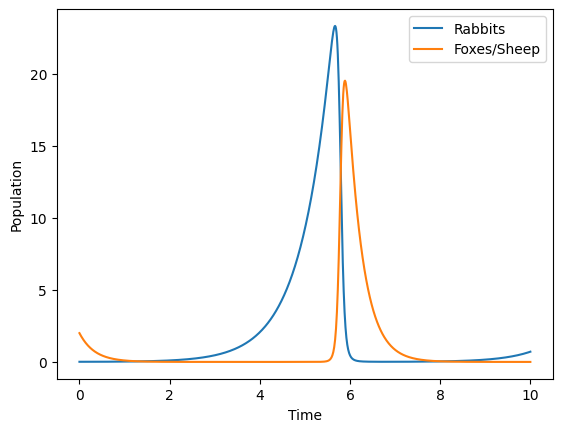

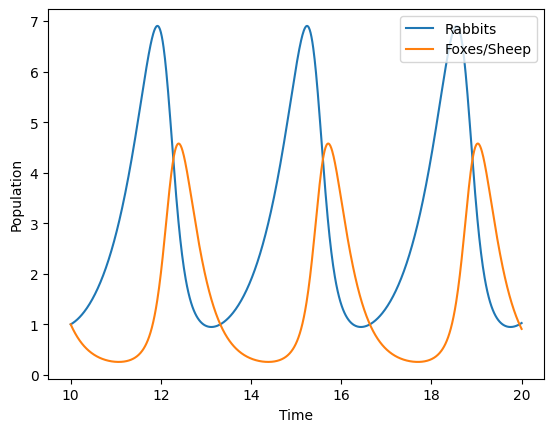

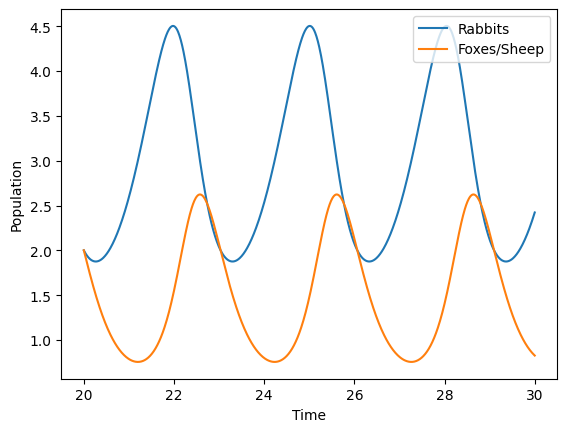

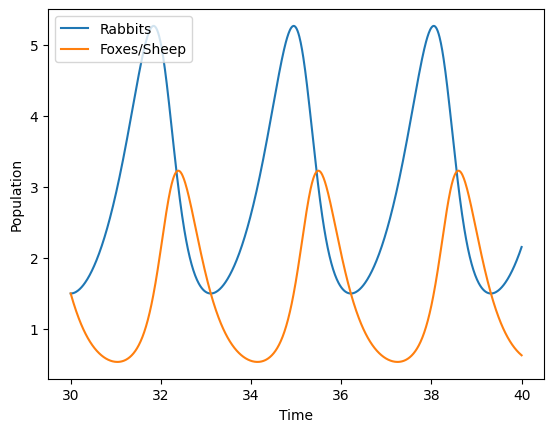

In [173]:
t0 = 0
r0, f0 = [0.01, 1, 2, 1.5], [2, 1, 2, 1.5]
abgd = [1.5, 1, 3, 1]
h = 0.01

t__, r__, f__ = pp_model(t0, h, r0, f0, abgd, r_dot, f_dot)

# Time evolution plots
for t00, r00, f00 in zip(t__, r__, f__):
    plt.plot(t00, r00, label='Rabbits')
    plt.plot(t00, f00, label='Foxes/Sheep')
    plt.legend()
    plt.xlabel("Time")
    plt.ylabel("Population")
    plt.show()


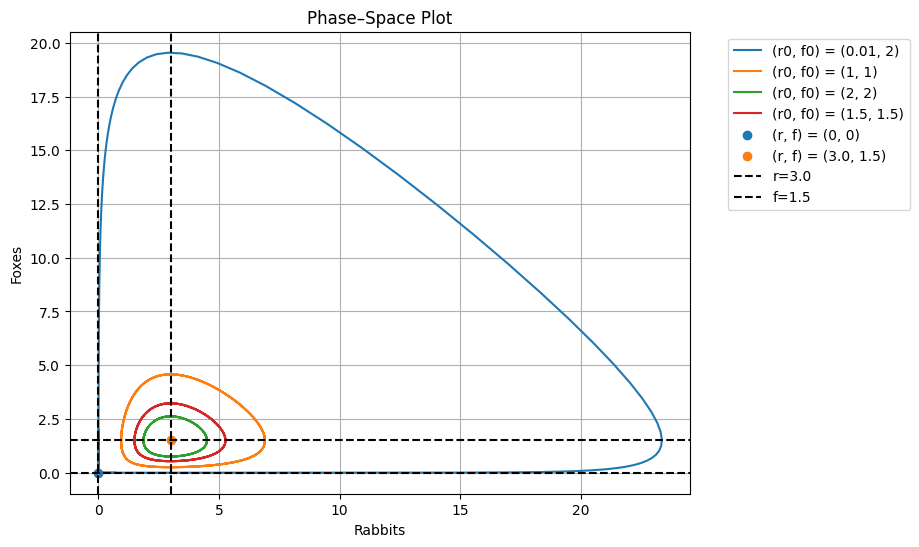

In [174]:
# Phase–space plot in a new figure
plt.figure(figsize=(8, 6))
for r00, f00 in zip(r__, f__):
    plt.plot(r00, f00, label=f'(r0, f0) = {r00[0], f00[0]}')

plt.scatter(0, 0, label='(r, f) = (0, 0)')
plt.scatter(abgd[2]/abgd[3], abgd[0]/abgd[1], label=f'(r, f) = ({abgd[2]/abgd[3]}, {abgd[0]/abgd[1]})')

plt.axvline(abgd[2]/abgd[3], c='black', linestyle='--', label=f'r={abgd[2]/abgd[3]}')
plt.axhline(abgd[0]/abgd[1], c='black', linestyle='--', label=f'f={abgd[0]/abgd[1]}')
plt.axvline(0, c='black', linestyle='--')
plt.axhline(0, c='black', linestyle='--')

plt.xlabel("Rabbits")
plt.ylabel("Foxes")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title("Phase–Space Plot")
plt.grid(True)
plt.show()

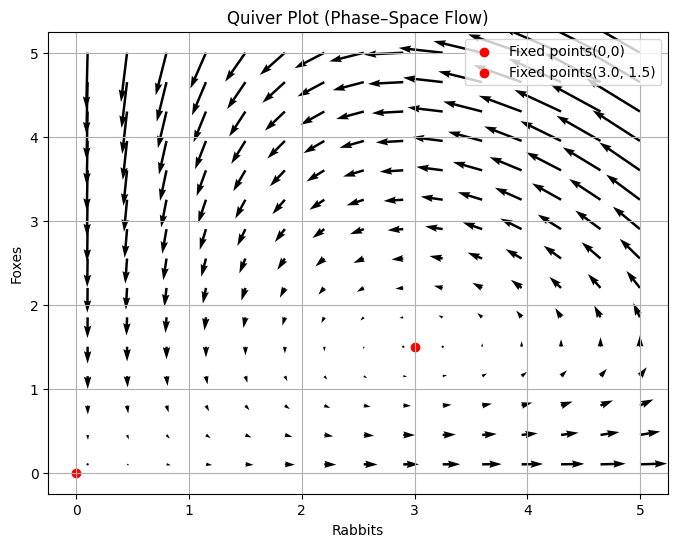

In [175]:
# Quiver plot
rp = np.linspace(0.1, 5, 15)
fp = np.linspace(0.1, 5, 15)
R, F = np.meshgrid(rp, fp)

dr_dt = r_dot(R, F, abgd)
df_dt = f_dot(R, F, abgd)

plt.figure(figsize=(8, 6))
plt.quiver(R, F, dr_dt, df_dt)

# Mark fixed points
plt.scatter(0, 0, color='red', label='Fixed points(0,0)')
plt.scatter(abgd[2]/abgd[3], abgd[0]/abgd[1],
            color='red', label=f'Fixed points({abgd[2]/abgd[3]}, {abgd[0]/abgd[1]})')

plt.xlabel("Rabbits")
plt.ylabel("Foxes")
plt.title("Quiver Plot (Phase–Space Flow)")
plt.grid(True)
plt.legend()
plt.show()


In [176]:
def r_dott(r, s, c_arr): 
    return c_arr[0] * r - c_arr[1] * r * s - c_arr[2] * r * r   # dr/dt

def s_dott(r, s, c_arr):  
    return c_arr[3] * s - c_arr[4] * r * s - c_arr[5] * s * s


In [177]:
# Initial conditions
r0, f0 = [0.01, 1, 2, 1.5], [2, 1, 2, 1.5]

abcdef = [3, 2, 1, 2, 1, 1]

# Time step
h = 0.01
t0 = 0

t__, r__, f__ = pp_model(t0, h, r0, f0, abcdef, r_dott, s_dott)

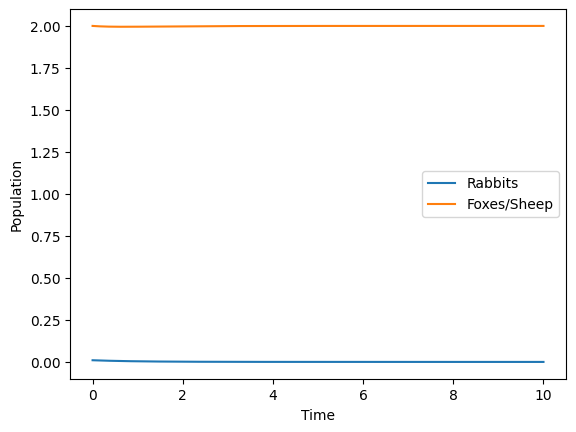

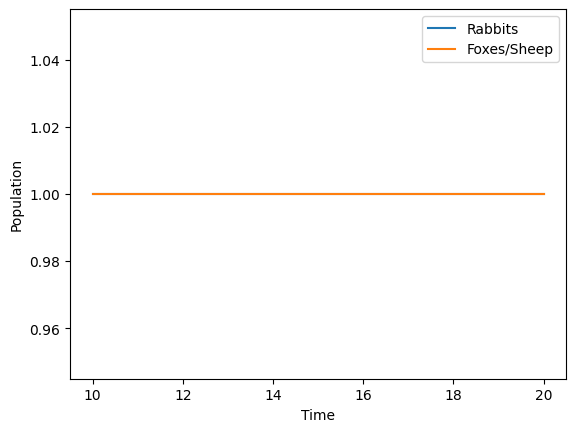

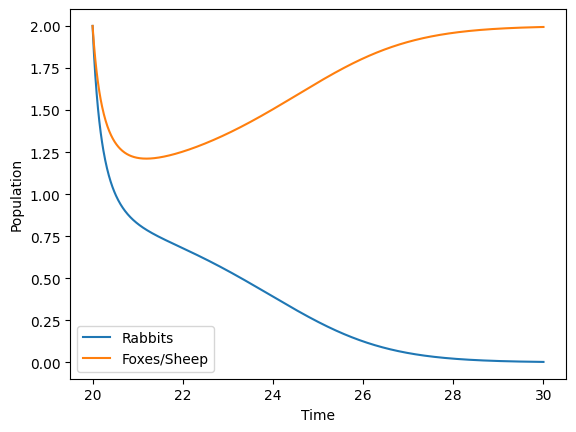

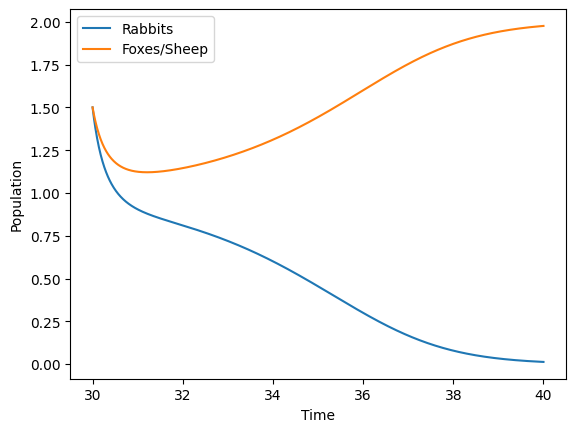

In [178]:
# Plotting
# fig, ax = plt.subplots(1, len(r__), figsize=(30, 7))
# for idx, (t00, r00, f00) in enumerate(zip(t__, r__, f__)):
#     ax[idx].plot(t00, r00, label='Rabbits')
#     ax[idx].plot(t00, f00, label='Foxes/Sheep')
#     ax[idx].set_title(f'Init: r0={r00[0]}, f0={f00[0]}')
#     ax[idx].legend()
# plt.show()

# Time evolution plots
for t00, r00, f00 in zip(t__, r__, f__):
    plt.plot(t00, r00, label='Rabbits')
    plt.plot(t00, f00, label='Foxes/Sheep')
    plt.legend()
    plt.xlabel("Time")
    plt.ylabel("Population")
    plt.show()

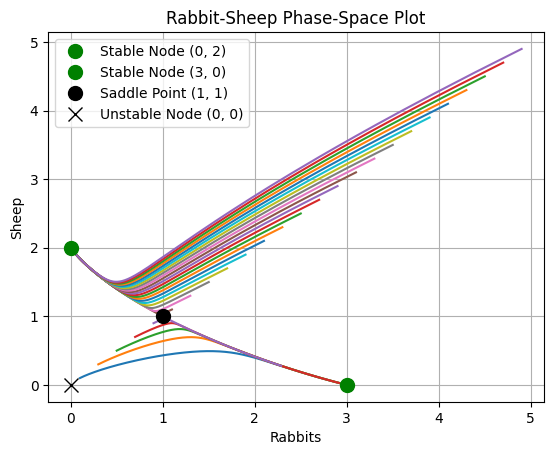

In [179]:
abcdef = [3, 2, 1, 2, 1, 1]

r0 = np.arange(0.1, 5, 0.2)
f0 = np.arange(0.1,5, 0.2)

# Time step
h = 0.01
t0 = 0

# Run model
t__, r__, f__ = pp_model(t0, h, r0, f0, abcdef, r_dott, s_dott)

for r00, f00 in zip(r__, f__):
    plt.plot(r00, f00)

plt.xlabel('Rabbits')
plt.ylabel('Sheep')
plt.grid(True)
plt.plot(0, 2, 'o', label='Stable Node (0, 2)', markersize=10, color='green')
plt.plot(3, 0, 'o', label='Stable Node (3, 0)', markersize=10, color='green')
plt.plot(1, 1, 'o', label='Saddle Point (1, 1)', markersize=10, color='black')
plt.plot(0, 0, 'x', label='Unstable Node (0, 0)', markersize=10, color='black')
plt.legend()
plt.title('Rabbit-Sheep Phase-Space Plot')
plt.show()

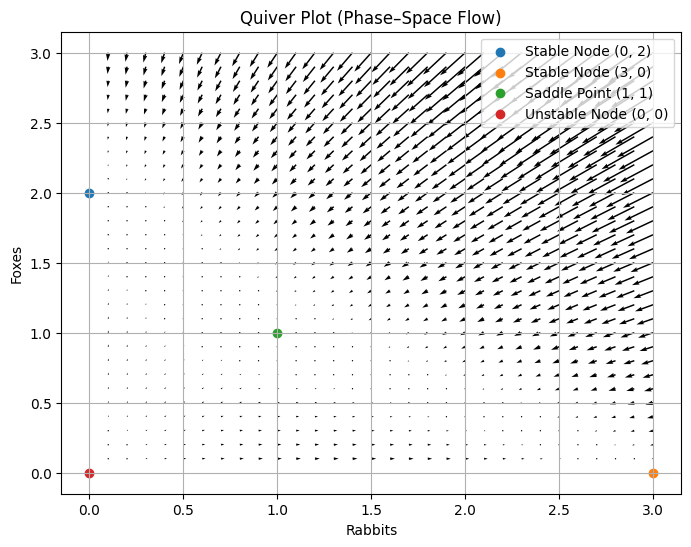

In [180]:
# Quiver plot
rp = np.linspace(0.1, 3, 30)
fp = np.linspace(0.1, 3, 30)
R, F = np.meshgrid(rp, fp)

dr_dt = r_dott(R, F, abcdef)
df_dt = s_dott(R, F, abcdef)

plt.figure(figsize=(8, 6))
plt.quiver(R, F, dr_dt, df_dt)

# Mark fixed points
plt.scatter(0, 2, label='Stable Node (0, 2)')
plt.scatter(3, 0, label='Stable Node (3, 0)')
plt.scatter(1, 1, label='Saddle Point (1, 1)')
plt.scatter(0, 0, label='Unstable Node (0, 0)')

plt.xlabel("Rabbits")
plt.ylabel("Foxes")
plt.title("Quiver Plot (Phase–Space Flow)")
plt.grid(True)
plt.legend()
plt.show()